# Stacking and Noise Reduction Analysis of ST9107

This notebook demonstrates the noise reduction achieved by stacking multiple frames of the target object **ST9107** observed on **2013-11-06**.

We perform:
1. Standard image correction, catalog-based rectification, and flux calibration on each frame.
2. Extraction of a 75x75 pixel crop around the target coordinate.
3. Stacking of different numbers of frames (from 1 to $N$) using median stacking and wavelet-based background subtraction.
4. Measurement of background noise in the stacked images as a function of the number of stacked frames.
5. Plotting of the noise levels against the theoretical $1/\sqrt{N}$ scaling curve.

In [1]:
import os
import sys
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
import astropy.units as u

# Set project root relative to package/dev_notebooks
project_root = os.path.abspath("../..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from package.src.astropipeline import astropipeline_etl as aple
from package.src.astropipeline import astropipeline_manager as aplmgr
from package.src.astropipeline import astropipeline_stack as apls

Querying observations from NoirLab archive...
Found 94 frames


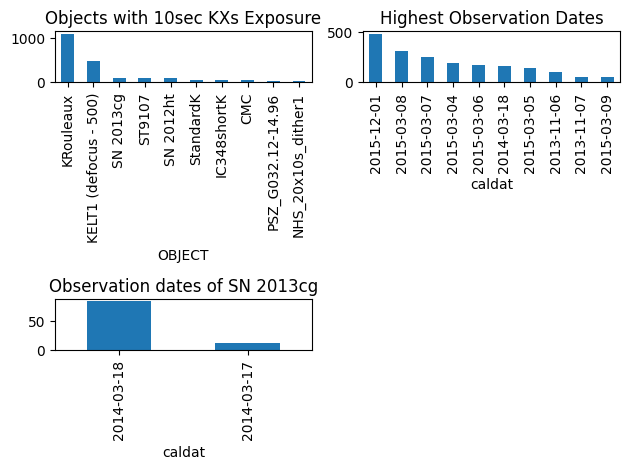

In [ ]:
# Query observations to find highest object collection on one night
print("Querying observations from NoirLab archive...")
study = aple.PipeStudy(telescope="kp4m", instrument="newfirm", max_returns=10000)
df = study.find_instcals()
df_st = df[(df["OBJECT"] == "SN 2013cg")].reset_index(drop=True)
print(f"Found {len(df_st)} frames")

plt.figure()
plt.subplot(2,2,1)
df['OBJECT'].value_counts()[:10].plot(kind='bar')
plt.title('Objects with 10sec KXs Exposure')

plt.subplot(2,2,2)
df["caldat"].value_counts()[:10].plot(kind='bar')
plt.title('Highest Observation Dates')

plt.subplot(2,2,3)
df_st['caldat'].value_counts()[:10].plot(kind='bar')
plt.title('Observation dates of SN 2013cg')

plt.gcf().tight_layout()
plt.show()

In [14]:
df_st = df[(df["OBJECT"] == "SN 2013cg") & (df["caldat"] == "2014-03-18")].reset_index(drop=True)

st_cropped_paths = aplmgr.study_single_object(
    df_st,
    ra=141.736542,dec=-24.783222,
    crop_size=75,
    output_folder="./dev_notebooks/stack_test/",
    study_name="stack_test"
    )

BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.